#    CREDIT LOAN SYSTEM PROJECT

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
 ab =  pd.read_csv("loan_approval.csv")

In [3]:
ab

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [4]:
categ_col = ab.select_dtypes(include = ["object"]).columns
nume_col = ab.select_dtypes(include = ["float64"]).columns


In [5]:
from sklearn.impute import SimpleImputer

In [6]:
categ_imp = SimpleImputer(strategy ="most_frequent")
ab[categ_col]= categ_imp.fit_transform(ab[categ_col])
nume_imp = SimpleImputer(strategy = "mean")
ab[nume_col] = nume_imp.fit_transform(ab[nume_col])

In [7]:
ab.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

[Text(0, 0, '621'), Text(0, 0, '379')]

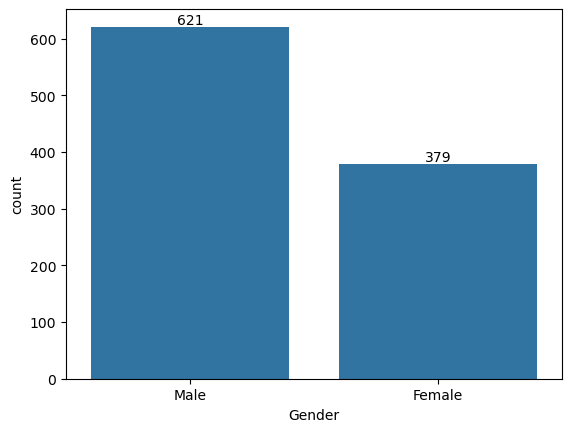

In [8]:
gender_count = ab["Gender"].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

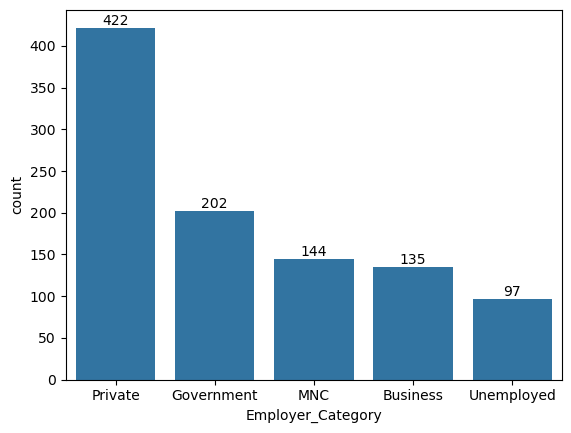

In [9]:
employee_category_count = ab["Employer_Category"].value_counts()
ac = sns.barplot(employee_category_count)
ac.bar_label(ac.containers[0])

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [11]:
le = LabelEncoder()

ab["Education_Level"] = le.fit_transform(ab["Education_Level"])
ab["Credit_Score"] = le.fit_transform(ab["Credit_Score"])

In [12]:
ab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   int64  
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [13]:
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Gender","Property_Area","Employer_Category"]
one = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")

encoded = one.fit_transform(ab[cols])

In [14]:
ab

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,85,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,No
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,69,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,No
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,122,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,Yes
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,29,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,No
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,169,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,7,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,1,Male,Unemployed,No
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,94,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,0,Female,Government,No
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,114,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,0,Male,MNC,No
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,196,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,0,Male,Private,Yes


In [15]:
encoded_df = pd.DataFrame(encoded, columns = one.get_feature_names_out(cols), index = ab.index)

In [16]:
ab = pd.concat([ab.drop(columns = cols),encoded_df],axis=1)

<Axes: >

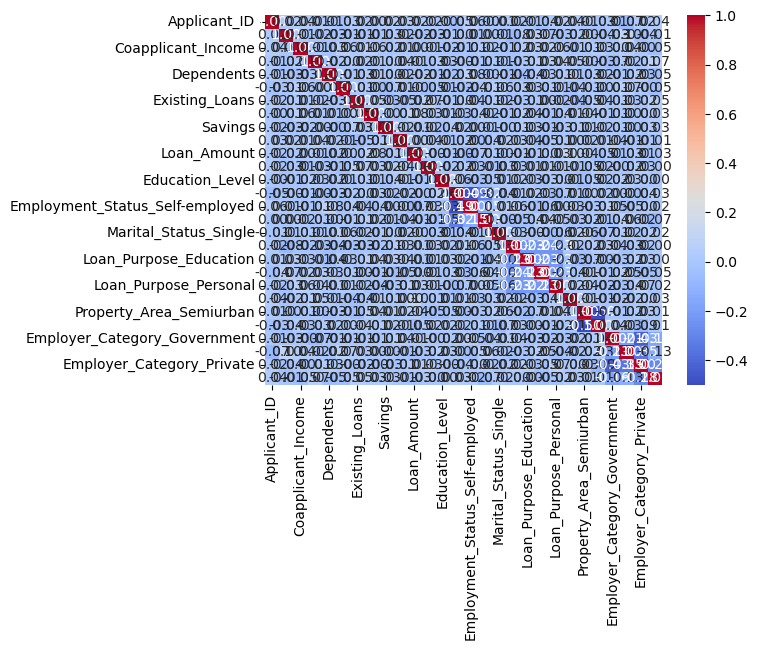

In [17]:
nums_cols= ab.select_dtypes(include = "number")
corr_matrix = nums_cols.corr()
sns.heatmap(
    corr_matrix,
    annot= True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [18]:
x = ab.drop(columns = "Loan_Approved")
y = ab["Loan_Approved"]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.2, random_state  = 42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [19]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(x_train, y_train)

y_pred = log_model.predict(x_test)
y_pred

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array(['No', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No',
       'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No',
       'Yes', 'No', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes',
       'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'Yes',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'Yes', 'No',
       'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'No',
       'No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'Yes',
       'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No',
       'Yes', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No',

In [20]:
ab

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Gender_Male,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.000000,1387.0,51.0,0.0,85,4.0,0.53,19403.000000,45638.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2.0,2860.000000,2679.0,46.0,3.0,69,2.0,0.30,2580.000000,49272.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,3.0,7390.000000,2106.0,25.0,2.0,122,4.0,0.20,13844.000000,6908.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,4.0,13964.000000,8173.0,40.0,2.0,29,3.0,0.31,9553.000000,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.000000,4223.0,31.0,2.0,169,1.0,0.29,9386.000000,37629.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,58.0,0.0,7,0.0,0.59,5370.000000,43563.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
996,997.0,3279.000000,6356.0,58.0,1.0,94,3.0,0.19,9940.452632,18361.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
997,998.0,15192.000000,8433.0,48.0,1.0,114,1.0,0.40,8581.000000,41335.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
998,999.0,9083.000000,7380.0,50.0,1.0,196,3.0,0.31,13491.000000,8933.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [21]:
ab.isnull().sum()

Applicant_ID                       0
Applicant_Income                   0
Coapplicant_Income                 0
Age                                0
Dependents                         0
Credit_Score                       0
Existing_Loans                     0
DTI_Ratio                          0
Savings                            0
Collateral_Value                   0
Loan_Amount                        0
Loan_Term                          0
Education_Level                    0
Loan_Approved                      0
Employment_Status_Salaried         0
Employment_Status_Self-employed    0
Employment_Status_Unemployed       0
Marital_Status_Single              0
Loan_Purpose_Car                   0
Loan_Purpose_Education             0
Loan_Purpose_Home                  0
Loan_Purpose_Personal              0
Gender_Male                        0
Property_Area_Semiurban            0
Property_Area_Urban                0
Employer_Category_Government       0
Employer_Category_MNC              0
E

In [22]:
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(x_train_scaled,y_train)
y_pred= log_model.predict(x_test_scaled)

In [23]:
ab["Loan_Approved"] = ab["Loan_Approved"].map({"Yes":1,"NO":0})

In [25]:
from sklearn.metrics import precision_score,accuracy_score,recall_score,f1_score,confusion_matrix

print("precision",  precision_score(y_test,y_pred,pos_label = "Yes"))
print("accuracy",  accuracy_score(y_test,y_pred))
print("f1",  f1_score(y_test,y_pred, pos_label = "Yes"))
print("reacall",  recall_score(y_test,y_pred, pos_label = "Yes"))
print("confusion_matrix",  confusion_matrix(y_test,y_pred))

precision 0.7868852459016393
accuracy 0.87
f1 0.7868852459016393
reacall 0.7868852459016393
confusion_matrix [[126  13]
 [ 13  48]]


In [28]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

gnb.fit(x_train_scaled,y_train)
y_pred = gnb.predict(x_test_scaled)

from sklearn.metrics import precision_score,accuracy_score,recall_score,f1_score,confusion_matrix

print("precision",  precision_score(y_test,y_pred,pos_label = "Yes"))
print("accuracy",  accuracy_score(y_test,y_pred))
print("f1",  f1_score(y_test,y_pred, pos_label = "Yes"))
print("reacall",  recall_score(y_test,y_pred, pos_label = "Yes"))
print("confusion_matrix",  confusion_matrix(y_test,y_pred))

precision 0.8070175438596491
accuracy 0.87
f1 0.7796610169491526
reacall 0.7540983606557377
confusion_matrix [[128  11]
 [ 15  46]]
